In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
data= pd.read_csv("/Users/akashdeepsangwan/Desktop/ML/ML/GitHub-Collab/Machine-Learning/K-mean_Clusturing/Wholesale customers data.csv")

In [5]:
data.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [6]:
print(data.shape)
print("/n/n")
print(data.dtypes)

(440, 8)
/n/n
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object


In [7]:
data.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [8]:
X = data.copy()
X.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
type(X_scaled) # it's a numpy array, convert it to a dataframe
X_scaled_df  = pd.DataFrame(X_scaled, columns = X.columns, index = X.index)
X_scaled_df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.448652,0.590668,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,1.448652,0.590668,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,1.448652,0.590668,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,-0.690297,0.590668,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,1.448652,0.590668,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347
5,1.448652,0.590668,-0.204806,0.334067,-0.297637,-0.496155,-0.228138,-0.026224
6,1.448652,0.590668,0.009950,-0.352316,-0.102849,-0.534512,0.054280,-0.347854
7,1.448652,0.590668,-0.349981,-0.113981,0.155359,-0.289315,0.092286,0.369601
8,-0.690297,0.590668,-0.477901,-0.291409,-0.185336,-0.545854,-0.244726,-0.275079
9,1.448652,0.590668,-0.474497,0.718495,1.151423,-0.394488,0.954031,0.203461


### Overall Steps
- Find K using Kmean++ / silhoutte score
- Once we have K then we can apply the kmean clusturing algorithm and get the label
- For the same K change the random state and check if produce the same clusters - To check it's statbility
- As we have the 8 features, in-order to check it's graph, we need to apply PCA for 2 dimensions
- Once PCA is applied, check the graphs for different random states and predict the quality of clustering


In [15]:

from sklearn.cluster import KMeans
wcss = []
for k in range(1,11) :
    kmeans = KMeans(n_clusters=k, init= "k-means++", n_init=10, random_state=42)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

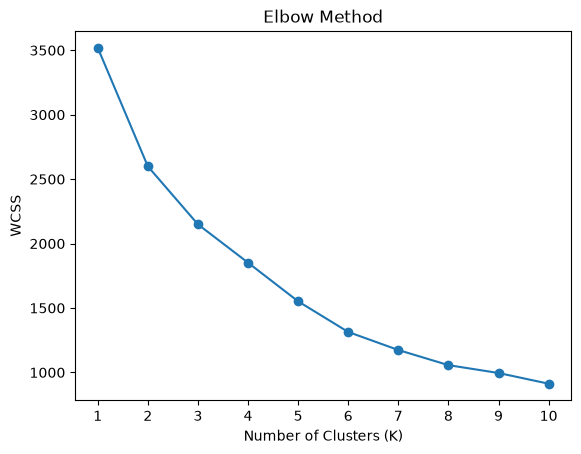

In [19]:
plt.plot(range(1,11), wcss, marker = 'o')
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### We don't even need to find WCSS, it better to just apply Silhoutte Directly to a K 

In [22]:
from sklearn.metrics import silhouette_score
silhouette_coeff = [] 

for k in range(2,11) :
    kmeans = KMeans(n_clusters = k, init= "k-means++", n_init = 10)
    kmeans.fit(X_scaled_df)
    score = silhouette_score(X_scaled_df, kmeans.labels_)
    silhouette_coeff.append(score)
    print(f"k = {k}  |  silhouette = {score:.4f}")


k = 2  |  silhouette = 0.3732
k = 3  |  silhouette = 0.3568
k = 4  |  silhouette = 0.3478
k = 5  |  silhouette = 0.3517
k = 6  |  silhouette = 0.3516
k = 7  |  silhouette = 0.3540
k = 8  |  silhouette = 0.3641
k = 9  |  silhouette = 0.3206
k = 10  |  silhouette = 0.3677


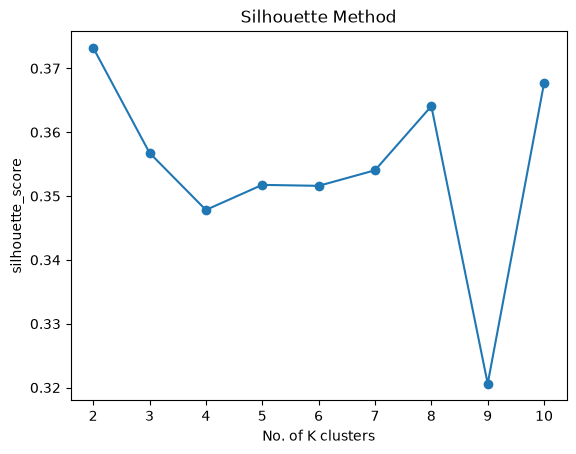

In [28]:
plt.plot(range(2,11), silhouette_coeff, marker = 'o')
# plt.xticks(range(2,11))
plt.xlabel("No. of K clusters")
plt.ylabel("silhouette_score")
plt.title("Silhouette Method")
plt.show()

In [29]:
# apply the algorithm now, as we have K=2 
kmeans = KMeans(n_clusters = 2, init = "k-means++", n_init = 10, random_state=4)
labels = kmeans.fit_predict(X_scaled_df)
X_clustered = X.copy() 
X_clustered["cluster"] = labels
X_clustered.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,0


In [ ]:
X_clustered["cluster"].unique() # confirm that we only have the data in two clusters

array([0, 1], dtype=int32)

### Checking the stability of the K with different random states

In [ ]:
label42 = KMeans(n_clusters= 2, init = "k-means++", n_init= 10, random_state=42).fit_predict(X_scaled_df)
label0= KMeans(n_clusters = 2, init = "k-means++", n_init= 10, random_state=0).fit_predict(X_scaled_df)
label7= KMeans(n_clusters=2, init = "k-means++", n_init = 10, random_state = 7).fit_predict(X_scaled_df)

print(pd.crosstab(label42, label0, rownames= ["rs=42"], colnames= ["rs=0"]))
print("")
print(pd.crosstab(label42, label7, rownames=["rs=42"], colnames= ["rs=7"]))

rs=0     0    1
rs=42          
0      305    1
1        0  134

rs=7     0    1
rs=42          
0      304    2
1        0  134


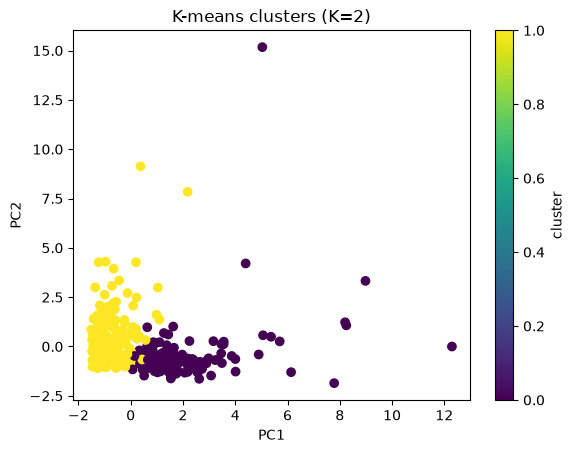

In [34]:
# we can try plotting it, but that will require here to apply PCA as we have the 8 features
from sklearn.decomposition import PCA 
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled_df) # it's a numpy 2d array

X_clustered["pc1"] = X_pca[:, 0] # all rows but 1st column
X_clustered["pc2"] = X_pca[:, 1]

plt.scatter(X_clustered["pc1"], X_clustered["pc2"], c= X_clustered["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters (K=2)")
plt.colorbar(label = "cluster")
plt.show()


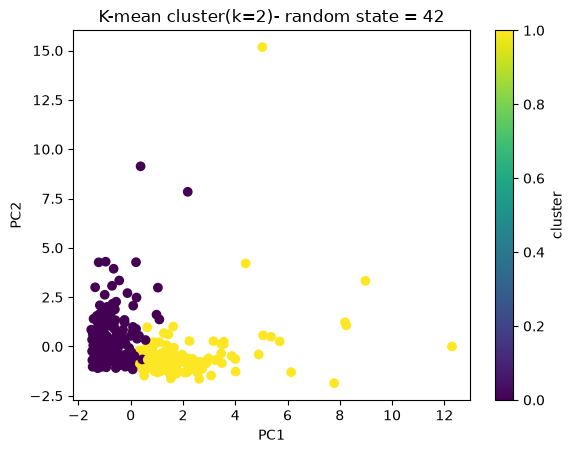

In [39]:
# now we check it for different random states as well
plt.scatter(X_pca[:,0], X_pca[:,1], c = label42)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-mean cluster(k=2)- random state = 42")
plt.colorbar(label= "cluster")
plt.show()

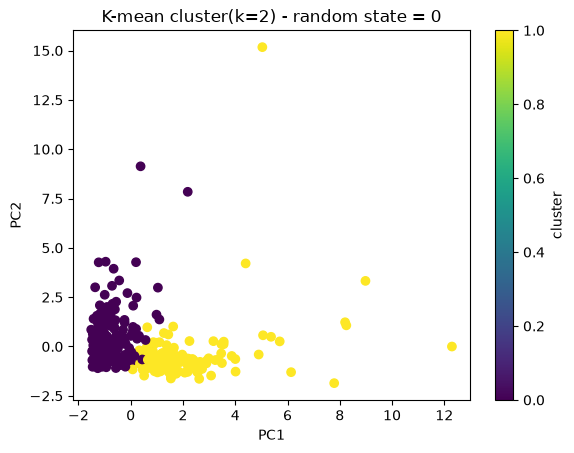

In [40]:
plt.scatter(X_pca[:,0], X_pca[:,1], c = label0)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-mean cluster(k=2) - random state = 0")
plt.colorbar(label= "cluster")
plt.show()

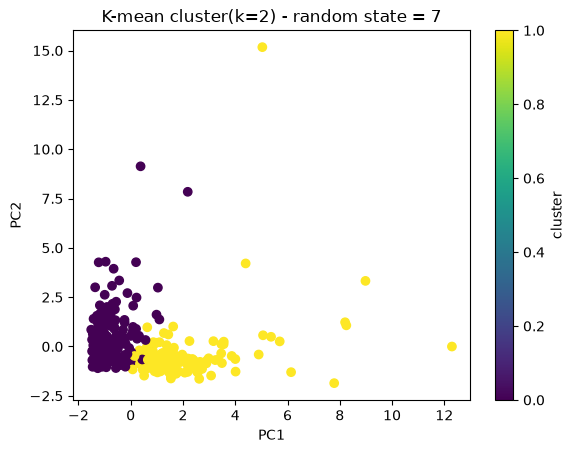

In [41]:
plt.scatter(X_pca[:,0], X_pca[:,1], c = label7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-mean cluster(k=2) - random state = 7")
plt.colorbar(label= "cluster")
plt.show()

### Review 
- Looking at the all 4 graphs the predicition seems to be stable - clusturing is good

- As it's same for random state = 0,42,7. The datapoints are at the same place but the colors are 
different for random state = 4
- This is totally fine, as we are using PCA, it doesn't use the random state so points won't change
- K- means doesn't care which group is called 0 or 1. 
- One run may call the big group 0 and the small group 1, Another run may swap those names
- As it can be also confirmed used 'Crosstab' as well. "print(pd.crosstab(label42, labels, rownames=["rs=42"], colnames=["rs=4"]))"